# California Housing – Regression Example

This notebook follows the **Hands-On Machine Learning** workflow: load the California Housing dataset, explore it, split train/test (including stratified and ID-based variants), perform **exploratory data analysis (EDA)**, and prepare for modeling. Key techniques include **train-test splitting**, **stratified sampling**, **correlation analysis**, and **spatial EDA**.

## Load the dataset

Fetch the **California Housing** dataset from scikit-learn with `as_frame=True` so we get a pandas DataFrame. This is the standard way to load this regression dataset (8 features, target `MedHouseVal`, ~20.6k samples).

In [2]:
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing(as_frame=True)

## Preview the data

Show the first 5 rows of the dataset with `.head()` to inspect column names, types, and value ranges. Quick sanity check that the data loaded correctly.

In [3]:
california_housing.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Dataset description

Print the built-in **DESCR** (description) of the dataset: number of instances, attributes, meaning of each feature, and references. Helps understand what each column represents before analysis.

In [4]:
print(california_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## Preview again

Display the first rows again (e.g. after reading the description) to associate column names with the documented meaning.

In [5]:

california_housing.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Type of the loaded object

`fetch_california_housing(as_frame=True)` returns a **Bunch** object (dict-like) with keys such as `data`, `target`, `frame`, `DESCR`. Checking `type()` clarifies how to access the DataFrame (e.g. `.frame`).

In [6]:
print(type(california_housing))


<class 'sklearn.utils._bunch.Bunch'>


## Use a single DataFrame

Assign the full dataset to `df` so we can use pandas operations (splits, plots, stats) on one variable. The `.frame` attribute is the combined features + target as a DataFrame.

In [7]:
df = california_housing.frame

## Value counts for one feature

**Technique: frequency distribution.** `value_counts()` shows how many times each value of `Population` appears. Useful to spot repeated values, potential identifiers, or discrete/categorical-like columns.

In [8]:
df['Population'].value_counts()

Population
891.0     25
1052.0    24
761.0     24
850.0     24
1227.0    24
          ..
3700.0     1
5558.0     1
6437.0     1
6242.0     1
5534.0     1
Name: count, Length: 3888, dtype: int64

## Summary statistics

**Technique: descriptive statistics.** `describe()` gives count, mean, std, min, quartiles, and max for each numeric column. Quick way to see scale, spread, and possible outliers before modeling or scaling.

In [9]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Distribution of all numeric columns

**Technique: univariate EDA.** `df.hist(bins=50)` draws one histogram per numeric column. Reveals skewness, multimodality, and scales; helps decide if log transform or scaling is needed later.

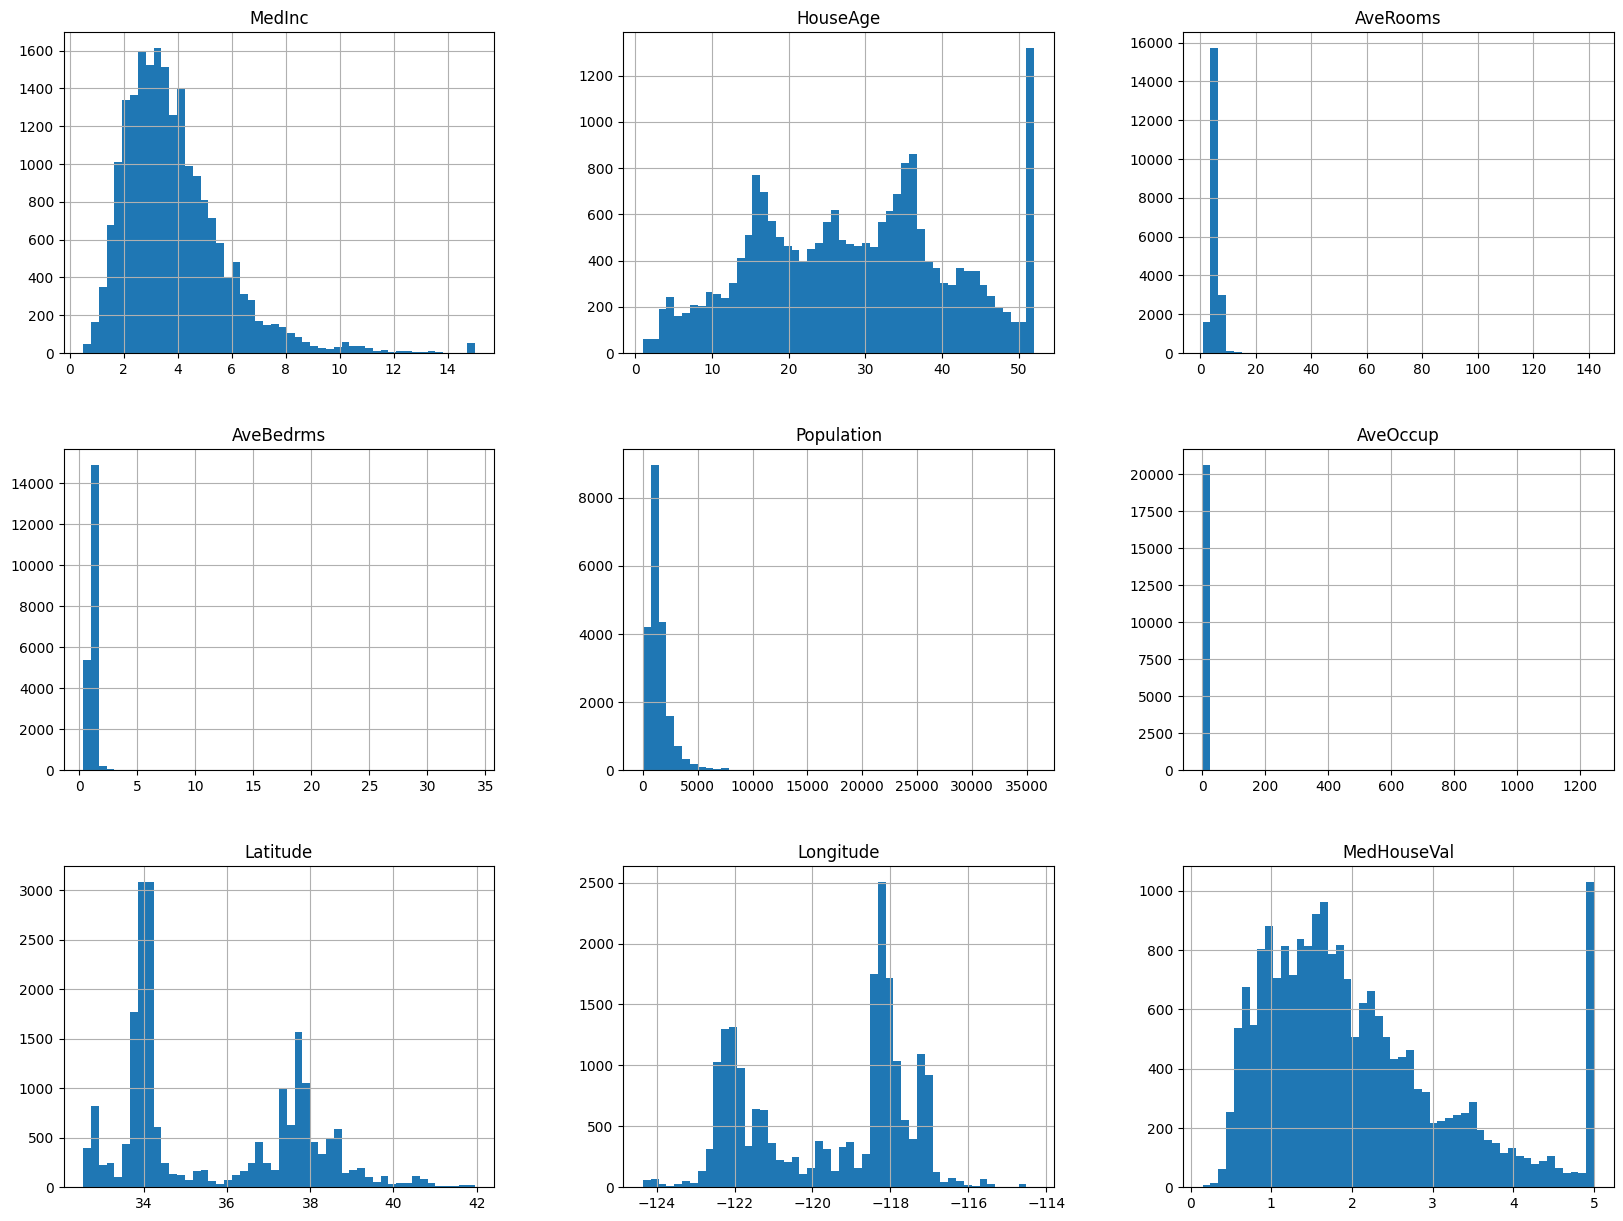

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(20, 15))
plt.show()

## Manual random train/test split

**Technique: random train-test split.** Shuffle row indices with `np.random.permutation`, then assign the first 20% to test and the rest to train. Simple way to reserve a holdout set; without a fixed seed, the split changes each run.

In [11]:
import numpy as np

def spli_train_test(data, test_radio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_radio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

## Apply the manual split

Call the custom split function with 20% test ratio. Produces `train_set` and `test_set` as DataFrames for later modeling and evaluation.

In [12]:
train_set, test_set = spli_train_test(df, 0.2)

## Train set size

Verify the number of rows in the training set (expect ~80% of total, e.g. 16512 for 20640 rows).

In [13]:
len(train_set)

16512

## Test set size

Verify the number of rows in the test set (expect ~20% of total, e.g. 4128).

In [14]:
len(test_set)

4128

## Stable test-set membership with hashing

**Technique: deterministic split by identifier.** Use CRC32 of a row identifier to decide train vs test. Same ID always maps to the same set, so when you add new data later, the split is repeatable and you avoid leakage from “seeing” test rows during exploration.

In [15]:
from zlib import crc32

def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

## Split by ID function

Assign each row to train or test based on a hash of an ID column (e.g. index). Rows with the same ID always get the same assignment, giving a **stable split** when the dataset is updated.

In [16]:
def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

## Deterministic split using a stable ID

Add a row index with `reset_index()`, then split using the ID-based function so the same rows go to train/test across runs. New rows get new IDs and consistently land in one set.

In [17]:
housing_with_id = df.reset_index()
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index") 

## Check type of housing_with_id

Confirm that `reset_index()` returns a DataFrame so the split function (which uses `.loc` and column access) works as expected.

In [18]:
type(housing_with_id)

pandas.core.frame.DataFrame

## Preview data with index

Show the first rows of `housing_with_id` to confirm the new `index` column is present for the ID-based split.

In [19]:
housing_with_id.head()

,index,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Train/test split with scikit-learn

**Technique: random train-test split.** Use `train_test_split` to split the dataframe into 80% train and 20% test with a fixed `random_state` for reproducibility. Standard way to reserve a holdout set for unbiased evaluation.

In [20]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)


## Create income categories for stratification

**Technique: binning (discretization).** Bin median income into 5 categories with `pd.cut` and plot their distribution. Enables **stratified sampling** so train and test have similar income proportions; the histogram confirms the category distribution before splitting.

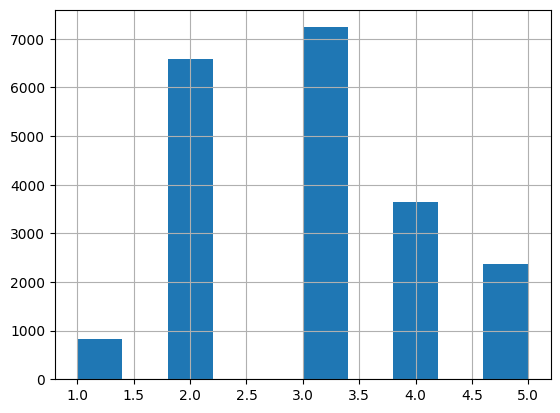

In [21]:
import pandas as pd
df["income_cat"] = pd.cut(df["MedInc"],
                    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                    labels=[1, 2, 3, 4, 5])
df["income_cat"].hist()
plt.show()




## Stratified train/test split

**Technique: stratified sampling.** Split so that train and test keep the same proportion of `income_cat` in each set. Improves reliability of performance estimates, especially when the target or important features are skewed or have rare categories.

In [22]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

## Check stratification proportions

Verify that the proportion of each income category in the training set matches the full dataset. Confirms that the stratified split preserved the distribution.

In [23]:
strat_train_set['income_cat'].value_counts() / len(strat_train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

## Remove temporary stratification column

Drop the `income_cat` column from both train and test sets so the data is back to its original feature set for modeling. Stratification was only used to create representative splits.

In [24]:
# remove the income_cat attribute so the data is back to its original state
for set in (strat_train_set, strat_test_set):
    set.drop("income_cat", axis=1, inplace=True)


## Work on training set only

Replace `df` with a copy of the stratified training set so that all further exploration and modeling use only training data. Avoids **data leakage** from the test set.

In [25]:
df = strat_train_set.copy()


## Geographic distribution

**Spatial EDA.** Scatter plot of longitude vs latitude with transparency (`alpha=0.1`) to show density of block groups. Confirms data aligns with California’s shape and highlights high-density regions.

**Check test set size**  
Verify that the test set has the expected number of rows (about 20% of the total).

## Geographic scatter with population and value

Scatter of longitude vs latitude with point size proportional to population and color to median house value. Reveals how location, density, and value relate (e.g. expensive coastal areas) and supports **spatial EDA**.

<Axes: xlabel='Longitude', ylabel='Latitude'>

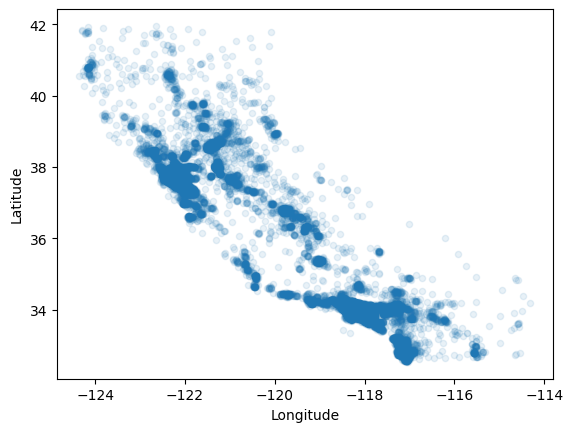

In [26]:
df.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.1)

## Correlation matrix

**Technique: correlation analysis.** Compute pairwise **Pearson correlations** between all numeric columns. Used to detect linear relationships and multicollinearity between features before modeling.

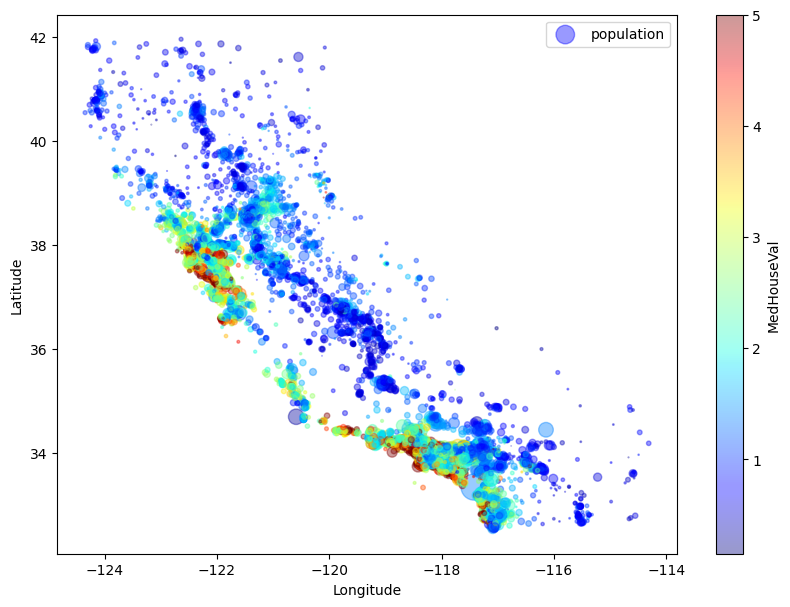

In [27]:
df.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.4, 
    s=df["Population"]/100, label="population", figsize=(10, 7), 
    c="MedHouseVal", cmap=plt.get_cmap("jet"), colorbar=True)
plt.legend()

## Correlation with target

Sort the correlation matrix by strength of correlation with the target (`MedHouseVal`) to see which features are most (and least) linearly related to house value. Pearson correlation near ±1 means strong linear association; near 0 means weak.

**Stable test-set membership with hashing**  
Define a function that uses CRC32 of an identifier to decide if a row belongs to the test set. Same ID always maps to the same set, so the split is deterministic and repeatable when new data is added.

## Quick look at the data

Display the first rows of `df` to confirm structure and values after the analysis steps above.

In [28]:
corr_matrix = df.corr()

## Scatter matrix (pair plot)

**Technique: multivariate EDA.** Plot pairwise relationships between selected features and the target. Off-diagonal subplots are scatter plots of two variables; the diagonal shows the distribution of each. Used to spot correlations and nonlinear patterns (e.g. MedInc vs MedHouseVal) before modeling.

In [29]:
corr_matrix["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.687151
AveRooms       0.146255
HouseAge       0.114146
AveOccup      -0.021991
Population    -0.026882
AveBedrms     -0.043294
Longitude     -0.047466
Latitude      -0.142673
Name: MedHouseVal, dtype: float64

**Split by ID function**  
Define a function that assigns each row to train or test based on a hash of an ID column (e.g. index). Rows with the same ID always get the same assignment, giving a stable split when data is appended.

In [30]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
12655,2.1736,29.0,5.485836,1.128895,2237.0,3.168555,38.52,-121.46,0.721
15502,6.3373,7.0,6.927083,1.113281,2015.0,2.623698,33.09,-117.23,2.796
2908,2.8750,44.0,5.393333,1.033333,667.0,2.223333,35.37,-119.04,0.827
14053,2.2264,24.0,3.886128,1.074534,898.0,1.859213,32.75,-117.13,1.125
20496,4.4964,27.0,6.096552,1.113793,1837.0,3.167241,34.28,-118.70,2.383


### Scatter matrix (pair plot)

**pandas.plotting.scatter_matrix** plots every pair of selected attributes: off-diagonal cells are scatter plots, diagonal shows the distribution of each variable. We use a subset of columns (MedInc, HouseAge, AveRooms, MedHouseVal) to spot relationships and correlation patterns quickly.

### Scatter plot: income vs median house value

A simple bivariate plot of **MedInc** (x) vs **MedHouseVal** (y) with low alpha to show density. Helps see if higher income correlates with higher house values and reveals potential nonlinearity or outliers.

### Correlation with the target

**df.corr()** computes the Pearson correlation matrix. We slice the column **MedHouseVal** to see each feature's linear correlation with the target. Values close to +1 or -1 indicate strong relationship; near 0 means weak. Useful for feature selection and understanding which variables drive the target.

array([[<Axes: xlabel='MedInc', ylabel='MedInc'>,
        <Axes: xlabel='HouseAge', ylabel='MedInc'>,
        <Axes: xlabel='AveRooms', ylabel='MedInc'>,
        <Axes: xlabel='MedHouseVal', ylabel='MedInc'>],
       [<Axes: xlabel='MedInc', ylabel='HouseAge'>,
        <Axes: xlabel='HouseAge', ylabel='HouseAge'>,
        <Axes: xlabel='AveRooms', ylabel='HouseAge'>,
        <Axes: xlabel='MedHouseVal', ylabel='HouseAge'>],
       [<Axes: xlabel='MedInc', ylabel='AveRooms'>,
        <Axes: xlabel='HouseAge', ylabel='AveRooms'>,
        <Axes: xlabel='AveRooms', ylabel='AveRooms'>,
        <Axes: xlabel='MedHouseVal', ylabel='AveRooms'>],
       [<Axes: xlabel='MedInc', ylabel='MedHouseVal'>,
        <Axes: xlabel='HouseAge', ylabel='MedHouseVal'>,
        <Axes: xlabel='AveRooms', ylabel='MedHouseVal'>,
        <Axes: xlabel='MedHouseVal', ylabel='MedHouseVal'>]], dtype=object)

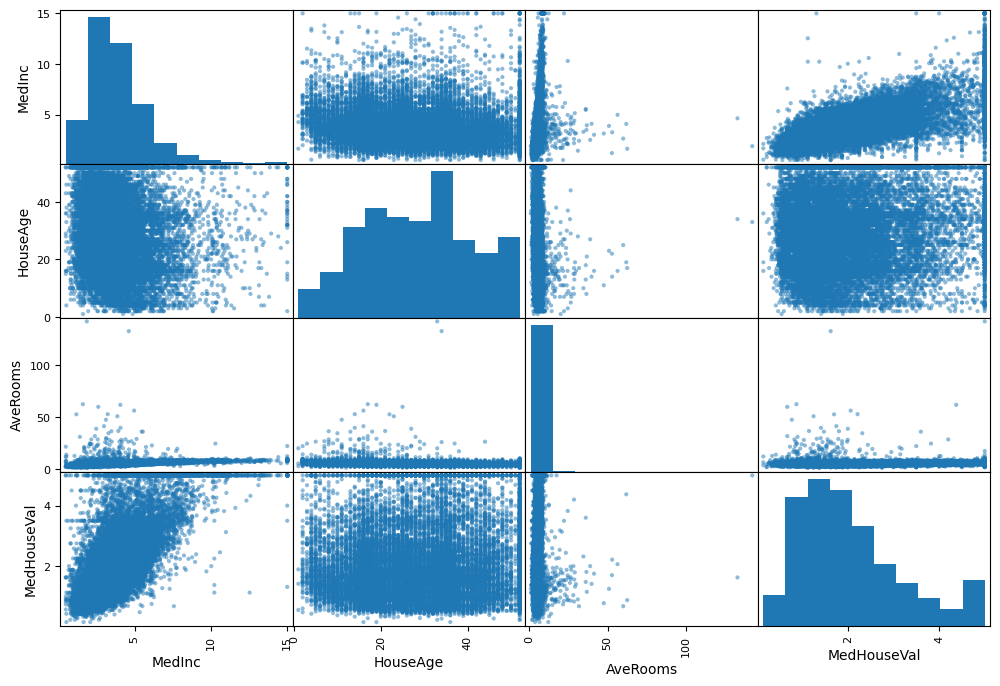

In [31]:
from pandas.plotting import scatter_matrix
attributes = ["MedInc", "HouseAge", "AveRooms", "MedHouseVal"]
scatter_matrix(df[attributes], figsize=(12, 8))

### Inspect the stratified training set

Display the stratified training set to confirm it has the expected number of rows and columns before we separate features and labels. We use this set for all model training and preprocessing.

<Axes: xlabel='MedInc', ylabel='MedHouseVal'>

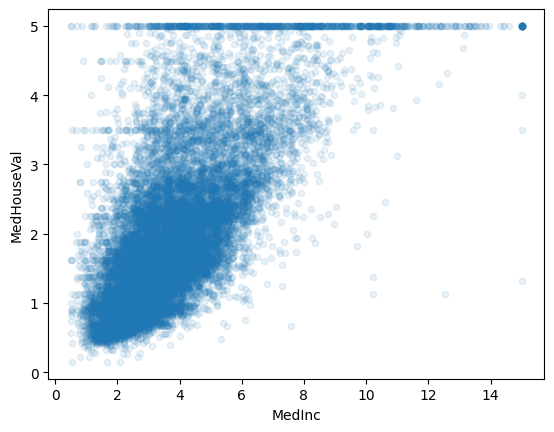

In [32]:
df.plot(kind="scatter", x="MedInc", y="MedHouseVal", alpha=0.1)

### Separate features and labels

We create **df** (feature matrix: all columns except MedHouseVal) and **df_labels** (target: MedHouseVal only). This is the standard split for supervised learning: the model will learn from **df** to predict **df_labels**.

In [33]:
corr_matrix = df.corr()
corr_matrix["MedHouseVal"]

MedInc         0.687151
HouseAge       0.114146
AveRooms       0.146255
AveBedrms     -0.043294
Population    -0.026882
AveOccup      -0.021991
Latitude      -0.142673
Longitude     -0.047466
MedHouseVal    1.000000
Name: MedHouseVal, dtype: float64

# Preparing the Data for Machine Learning Algorithms

In [34]:
strat_train_set

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
12655,2.1736,29.0,5.485836,1.128895,2237.0,3.168555,38.52,-121.46,0.721
15502,6.3373,7.0,6.927083,1.113281,2015.0,2.623698,33.09,-117.23,2.796
2908,2.8750,44.0,5.393333,1.033333,667.0,2.223333,35.37,-119.04,0.827
14053,2.2264,24.0,3.886128,1.074534,898.0,1.859213,32.75,-117.13,1.125
20496,4.4964,27.0,6.096552,1.113793,1837.0,3.167241,34.28,-118.70,2.383
...,...,...,...,...,...,...,...,...,...
15174,5.0900,14.0,6.658342,1.229770,2026.0,2.023976,33.03,-117.07,2.685
12661,2.8139,15.0,5.571932,1.002821,4769.0,3.363188,38.51,-121.42,0.904
19263,3.1797,48.0,4.110465,0.965116,458.0,2.662791,38.44,-122.72,1.404
19140,4.1964,14.0,6.297405,1.157685,1208.0,2.411178,38.31,-122.70,2.581


### Separate features (X) and labels (y)

We create **df** by dropping the target column **MedHouseVal** from the stratified training set, and **df_labels** as a copy of **MedHouseVal**. The model will be trained on **df** to predict **df_labels**.

In [37]:
df = strat_train_set.drop("MedHouseVal", axis=1)
df_labels = strat_train_set["MedHouseVal"].copy()

## Data Cleaning

In [39]:
median = df["AveRooms"].median()
df["AveRooms"].fillna(median, inplace=True)

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_54040\2386262271.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["AveRooms"].fillna(median, inplace=True)


A simple imputer strategy is a basic method for handling missing data by replacing absent values with a single estimated value based on a summary statistic of the other available data within each feature column. The most common strategies are mean, median, most frequent, and constant value

In [42]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
imputer.fit(df)

,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


### Imputer statistics (learned values)

**SimpleImputer** fits the mean (or median) per column from the training data. **imputer.statistics_** holds those learned values—one per feature. We use them to fill missing values in transform; inspecting them confirms what the imputer will use.

### Compare with raw medians

**df.median().values** gives the column medians from the original DataFrame. Comparing with **imputer.statistics_** shows that the imputer used the same (or very similar) values when strategy is `"median"`.

### Transform the data with the fitted imputer

**imputer.transform(df)** replaces missing values in **df** with the fitted statistics (e.g. median per column). The result is a NumPy array **X** with the same number of rows and columns, ready for scaling or model input. We always fit on training data only and use the same imputer to transform train and test.

### Shape of the feature matrix

**X.shape** confirms the dimensions after imputation: (n_samples, n_features). We use this to ensure the array is correct before passing it to a model or scaler.

In [44]:
imputer.statistics_

array([ 3.87588428e+00,  2.86534036e+01,  5.44040595e+00,  1.09841751e+00,
        1.41968738e+03,  3.09646921e+00,  3.56393144e+01, -1.19575635e+02])

### Compare with raw medians

**df.median().values** gives the column medians from the DataFrame. You can compare these with **imputer.statistics_** to confirm the imputer is using the same central tendency (e.g. median) per column.

In [45]:
df.median().values

array([ 3.54155000e+00,  2.90000000e+01,  5.23234164e+00,  1.04859934e+00,
        1.16400000e+03,  2.81766108e+00,  3.42600000e+01, -1.18510000e+02])

### Transform training data with the imputer

**imputer.transform(df)** fills missing values in **df** using the statistics learned in **fit**. The result **X** is a NumPy array of shape (n_samples, n_features), ready for the next step (e.g. scaling or model).

In [46]:
X = imputer.transform(df)

### Check feature matrix shape

**X.shape** returns (n_samples, n_features). We use it to confirm dimensions after imputation before passing **X** to a scaler or model.

In [49]:
X.shape

(16512, 8)

## Feature Scaling

### Take a small sample for quick prediction check

We take the first 5 rows of **df** and **df_labels** to compare model predictions with actual labels. This is a sanity check before computing full-set metrics like RMSE.

**!!!Cursor Explain!!! — What is a Pipeline?**

A **Pipeline** (sklearn) is a chain of preprocessing and model steps that run in order. Instead of calling `imputer.fit_transform()`, then `adder.transform()`, then `scaler.fit_transform()` by hand, you give Pipeline a list of `(name, estimator)` steps. When you call **fit_transform** (or **fit** then **transform**), it runs each step in sequence: the output of one step is the input of the next. Benefits: (1) one call does all preprocessing, (2) you avoid leaking test data (fit is only on train), (3) hyperparameter tuning and saving the model are easier.

**In simple words, the code does this:** It builds a pipeline with three steps: (1) **imputer** — fill missing values with the column median; (2) **attribs_adder** — add custom features (e.g. rooms per household); (3) **std_scaler** — standardize features to mean 0 and variance 1. Then **fit_transform(housing_num)** runs all three on the training data in one go and returns the final numeric matrix **housing_num_tr** ready for the model.

### Print model predictions on the sample

**lin_reg.predict(some_data)** returns the linear model's predictions for the 5 sample points. We print them to compare with the real labels in the next cell.

### Print actual labels for the sample

We print the true median house values (df_labels) for the same 5 rows. Comparing with the predictions from the previous cell gives a quick sense of how well the model is doing.

### Linear regression training-set RMSE

**LinearRegression** (sklearn) fits a linear model (ordinary least squares). We predict on the full training set, then use **mean_squared_error** to compute MSE and take the square root for RMSE (same units as the target). This is the in-sample error; cross-validation or test-set RMSE is a better measure of generalization.

### Linear Regression — fit on training data

**LinearRegression** (sklearn) fits an ordinary least squares model: it finds the coefficients that minimize the sum of squared errors between predictions and **df_labels**. We call **fit(df, df_labels)** on the training set; then we use the model to predict and compute RMSE in the following cells.

## Select and Train a Model

In [52]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(df, df_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Sample of 5 points for a quick prediction check

We take the first 5 rows of **df** and **df_labels** to compare the model's predictions with the actual target values in the next two cells.

In [54]:
some_data = df.iloc[:5]
some_labels = df_labels.iloc[:5]

### Print predictions for the sample

**lin_reg.predict(some_data)** returns the model's predictions for the 5 sample points. We print them to compare with the real labels in the next cell.

In [56]:
print("Predictions:", lin_reg.predict(some_data))

Predictions: [0.95124793 2.84148809 1.63345708 1.61512576 2.4572297 ]


### Print actual labels for the sample

We print the true median house values for the same 5 rows. Compare with the predictions above to get a quick sense of model accuracy.

### Linear regression training-set RMSE

We predict on the full training set, compute **mean_squared_error** (MSE), and take the square root to get RMSE in the same units as the target. This is in-sample error; cross-validation or test-set RMSE is a better measure of generalization.

In [57]:
print("Labels:", list(some_labels))

Labels: [0.721, 2.796, 0.827, 1.125, 2.383]


### Compute training-set RMSE for Linear Regression

We use **mean_squared_error** from sklearn to compute MSE between **df_labels** and the model's predictions on **df**, then take the square root to get RMSE. This measures in-sample fit; use cross-validation or test set for generalization.

In [58]:
from sklearn.metrics import mean_squared_error
df_prediction = lin_reg.predict(df)
lin_mse = mean_squared_error(df_labels, df_prediction)
lin_rmse = np.sqrt(lin_mse)
lin_mse

0.5287374080178308

## Using Decision Tree Regressor

**!!!Cursor Explain!!! — What is the Decision Tree Regressor model?**

A **Decision Tree Regressor** splits the data recursively by asking yes/no questions on features (e.g. “Is MedInc &lt; 3?”). Each leaf stores the average target value of the training points that reached it. To predict, a new sample is pushed down the tree until it lands in a leaf; that leaf’s value is the prediction. The model is easy to interpret (you can read the splits) but tends to **overfit** if the tree is deep. In the next cell we fit one with default settings and later use cross-validation to get a fair RMSE.

In [60]:
# Decision Tree Regressor: see the markdown cell above for an explanation of the model.
# We fit it in the next cell and evaluate with RMSE and cross-validation.


### Fit Decision Tree and predict on training set

**DecisionTreeRegressor()** creates a tree with default parameters. We **fit** it on **df** (features) and **df_labels** (target). Then we predict on the same data and compute RMSE. Training-set RMSE is often overly optimistic; the next cells use cross-validation for a better estimate.

In [62]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(df, df_labels)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### K-fold cross-validation for the Decision Tree

**cross_val_score** with **cv=10** trains the tree on 9 folds and evaluates on the 10th, rotating so every fold is used as validation once. We use **scoring="neg_mean_squared_error"** and convert to RMSE. This gives a more reliable performance estimate and helps spot overfitting (e.g. low training RMSE but higher CV RMSE).

### K-fold cross-validation for the Decision Tree

We use **cross_val_score** with **cv=10** to train the tree on 9 folds and evaluate on the 10th, rotating so each fold is the validation set once. **scoring="neg_mean_squared_error"** is used; we take the square root to report RMSE per fold. This gives a more reliable performance estimate than a single split.

### Decision Tree training-set RMSE

We compute MSE with **mean_squared_error** and take the square root for RMSE. Comparing this with the linear regression RMSE and with cross-validation RMSE (next) shows whether the tree is overfitting.

### 10-fold cross-validation for the Decision Tree

**cross_val_score** with **cv=10** and **scoring="neg_mean_squared_error"** trains the tree on 9 folds and evaluates on the 10th. We convert to RMSE with **np.sqrt(-scores)**. This gives a stable estimate of how the tree generalizes and helps detect overfitting.

In [64]:
df_predictions = tree_reg.predict(df)
tree_mse = mean_squared_error(df_labels, df_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(2.789721946370892e-16)

### K-fold cross-validation for Decision Tree

We use **cross_val_score** with **cv=10** to get a robust estimate of the tree's RMSE. Each fold trains on 9 parts and validates on 1; we take the square root of the negative MSE to report RMSE per fold.

In [70]:
# using k-fold cross-validation for the subsets for training

from sklearn.model_selection import cross_val_score 
scores = cross_val_score(tree_reg, df, df_labels, scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

### K-fold cross-validation for the Decision Tree

**cross_val_score** (sklearn) splits the data into `cv=10` folds, trains the model on 9 and evaluates on 1, rotating so each fold is used as validation once. We use `scoring="neg_mean_squared_error"` and take the square root to get RMSE per fold. This gives a more reliable performance estimate than a single train/test split and helps detect overfitting (e.g. if training RMSE is much lower than cross-validation RMSE).

Scikit-Learn’s cross-validation features expect a utility function
(greater is better) rather than a cost function (lower is better), so
the scoring function is actually the opposite of the MSE (i.e., a neg‐
ative value), which is why the preceding code computes -scores
before calculating the square root.

In [72]:
def display_scores(scores):
    print("Scores: ", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores:  [0.78037052 0.72506988 0.70473986 0.7259682  0.73259949 0.76164936
 0.73455903 0.75309594 0.67914344 0.72121262]
Mean: 0.7318408331119259
Standard deviation: 0.02721799650103888


### Custom function to display cross-validation scores

`display_scores()` prints the individual fold scores and their mean ± standard deviation. Used after **cross_val_score** to inspect the distribution of RMSE across folds.

In [ ]:
# !!!Cursor Explain!!! — What is Ensemble Learning? See the markdown cell above (Random Forest Regressor) for the explanation.

### Random Forest Regressor — Ensemble Learning

**!!!Cursor Explain!!! — What is Ensemble Learning?**

**Ensemble learning** means combining multiple models (e.g. many decision trees) to make a prediction. Instead of trusting one model, we average or vote over many. **Random Forest** builds many decision trees on random subsets of the data and features; each tree votes, and the final prediction is the average (for regression). This usually reduces overfitting and improves accuracy compared to a single tree.

**In this cell:** We use **RandomForestRegressor** from sklearn: fit on training data, predict on the same data, and compute RMSE. Later we use cross-validation and grid search to tune and evaluate it properly.

In [75]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor()
forest_reg.fit(df, df_labels)
forest_prediction = forest_reg.predict(df)
forest_mse = mean_squared_error(df_labels, forest_prediction) 
forest_rmse = np.sqrt(forest_mse)
forest_rmse

np.float64(0.1908845146307198)

### Cross-validation for Random Forest

**cross_val_score** fits the forest on different train folds and evaluates on the corresponding validation fold (here 10 folds). We use `scoring="neg_mean_squared_error"` and take the square root to report RMSE. This gives a robust estimate of how the model generalizes.

In [76]:
scores = cross_val_score(forest_reg, df, df_labels, scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-scores)

### Display cross-validation RMSE scores

We use the custom `display_scores()` function to show the mean and standard deviation of the 10-fold RMSE scores for the Random Forest model. This gives a more stable performance estimate than a single train/test split.

In [77]:
display_scores(forest_rmse_scores)

Scores:  [0.54053926 0.49479155 0.47121096 0.52084502 0.47907283 0.51677312
 0.54326007 0.50395382 0.48270602 0.53407231]
Mean: 0.5087224957285719
Standard deviation: 0.024978828569970107


### Grid search for hyperparameter tuning

**GridSearchCV** (sklearn) trains a model for every combination of parameters in `param_grid` and uses cross-validation to pick the best one. Here we tune the Random Forest's `n_estimators`, `max_features`, and `bootstrap` to minimize negative MSE. Fitting may take a few minutes.

In [78]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]

forest_reg = RandomForestRegressor()

grid_search = GridSearchCV(forest_reg, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)

grid_search.fit(df, df_labels)

,estimator,RandomForestRegressor()
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


### Best hyperparameters found by grid search

`best_params_` returns the combination of parameters that achieved the best cross-validation score. We use it to know which settings to use for the final model.

In [79]:
grid_search.best_params_

{'max_features': 4, 'n_estimators': 30}

### Best estimator from grid search

The best full model (with the chosen hyperparameters) is stored in `best_estimator_`. We can use it for prediction or inspect its configuration.

In [80]:
grid_search.best_estimator_

,n_estimators,30
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Inspect grid search results

We iterate over `cv_results_` to print the mean RMSE (negated and square-rooted) for each hyperparameter combination. This helps see how performance varies with the tuned parameters.

In [81]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

0.6096901682042682 {'max_features': 2, 'n_estimators': 3}
0.5387344805804947 {'max_features': 2, 'n_estimators': 10}
0.509626563373693 {'max_features': 2, 'n_estimators': 30}
0.6049185859583378 {'max_features': 4, 'n_estimators': 3}
0.5342532715814776 {'max_features': 4, 'n_estimators': 10}
0.5069761559556835 {'max_features': 4, 'n_estimators': 30}
0.6047813320979648 {'max_features': 6, 'n_estimators': 3}
0.5387109625655084 {'max_features': 6, 'n_estimators': 10}
0.5166385896837945 {'max_features': 6, 'n_estimators': 30}
0.6018118645187632 {'max_features': 8, 'n_estimators': 3}
0.5385580285309897 {'max_features': 8, 'n_estimators': 10}
0.5208435165084248 {'max_features': 8, 'n_estimators': 30}
0.5903297619340048 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
0.5200204699881416 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
0.5859833470848851 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
0.5189732294788647 {'bootstrap': False, 'max_features': 3, 'n_

### Feature importances from the best model

**RandomForestRegressor** provides `feature_importances_`: each feature's contribution to reducing impurity across the trees. We sort and display them to see which attributes (e.g. MedInc, location) matter most for predicting median house value.

In [83]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([0.44127515, 0.05707341, 0.08623439, 0.03775381, 0.0313498 ,
       0.13453913, 0.10999402, 0.1017803 ])

### Inspect the training data

Quick look at the first rows of the training DataFrame to confirm feature columns before final evaluation.

In [84]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
12655,2.1736,29.0,5.485836,1.128895,2237.0,3.168555,38.52,-121.46
15502,6.3373,7.0,6.927083,1.113281,2015.0,2.623698,33.09,-117.23
2908,2.8750,44.0,5.393333,1.033333,667.0,2.223333,35.37,-119.04
14053,2.2264,24.0,3.886128,1.074534,898.0,1.859213,32.75,-117.13
20496,4.4964,27.0,6.096552,1.113793,1837.0,3.167241,34.28,-118.70


### Prepare attribute list for test features

We define the same feature columns used in training so the test DataFrame can be passed to the model in the same order.

### Final model evaluation on test set

We take **best_estimator_** from grid search, prepare the test features (same preprocessing as training), predict on **X_test**, and compute the final RMSE. This is the unbiased estimate of how the model will perform on new data.

### Evaluate the best model on the test set

We take the best estimator from grid search, prepare **X_test** and **y_test** from the stratified test set (same preprocessing as training), predict, and compute the final RMSE. This is the unbiased estimate of model performance on new data.

In [87]:
attributes = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedroms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.44127514768950354), 'MedInc'),
 (np.float64(0.13453912700525414), 'AveOccup'),
 (np.float64(0.10999402059740593), 'Latitude'),
 (np.float64(0.10178030089688142), 'Longitude'),
 (np.float64(0.08623438753575126), 'AveRooms'),
 (np.float64(0.057073414302891846), 'HouseAge'),
 (np.float64(0.03775380587398983), 'AveBedroms'),
 (np.float64(0.03134979609832196), 'Population')]

### Final evaluation: best model on test set

We use **grid_search.best_estimator_** as the final model, prepare **X_test** and **y_test** from the stratified test set, predict, and compute RMSE. This is the unbiased estimate of performance on new data.

### Inspect the test set

Quick look at the stratified test set to confirm it has the same structure as the training data before running the final evaluation.

### Final model test-set evaluation

We take the best estimator from grid search, prepare test features and target from **strat_test_set**, predict, and compute the final RMSE. This is the main metric for reporting model performance.

In [88]:
strat_test_set

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
5241,8.2816,29.0,6.715625,1.054167,2184.0,2.275000,34.12,-118.39,5.00001
17352,5.0099,24.0,7.137809,1.084806,855.0,3.021201,34.89,-120.42,1.62500
3505,4.3839,36.0,5.283636,0.981818,808.0,2.938182,34.25,-118.45,2.04600
7777,3.2708,35.0,5.491694,1.079734,1072.0,3.561462,33.91,-118.10,1.59700
14155,4.3529,38.0,6.154723,1.000000,1495.0,2.434853,32.77,-117.07,1.84000
...,...,...,...,...,...,...,...,...,...
12182,2.8170,19.0,6.108696,1.160326,1207.0,3.279891,33.72,-117.29,1.10000
7275,2.1615,33.0,3.138298,1.042553,1270.0,4.503546,33.99,-118.24,1.18800
17223,4.7000,43.0,4.974860,0.955307,663.0,1.851955,34.44,-119.72,2.93800
10786,4.9125,30.0,5.026699,1.000000,1081.0,2.623786,33.63,-117.91,3.35700


### Run the best model on the test set

We use the best estimator from **GridSearchCV**, build **X_test** and **y_test** from the stratified test set, and compute the final RMSE. This gives the unbiased performance estimate on held-out data.

In [ ]:
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop("MedHouseVal", axis=1)
y_test = strat_test_set["MedHouseVal"].copy()

final_predictions = final_model.predict(X_test)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

### Final model evaluation on the test set

We take the best estimator from grid search, prepare the test features (same preprocessing as training), predict, and compute the final RMSE on the held-out test set. This is the unbiased estimate of model performance.

In [92]:
final_rmse

np.float64(0.4915768647232201)

### Confidence interval for the test RMSE

We use **scipy.stats** to compute a 95% confidence interval for the true RMSE. The squared errors are assumed to be normally distributed; we get the interval bounds and then take the square root to express the interval in the same units as the target (median house value).

In [93]:
from scipy import stats
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
loc=squared_errors.mean(),
scale=stats.sem(squared_errors)))

array([0.47121307, 0.51112999])